In [2]:
import scipy as sp
from scipy.optimize import curve_fit
from scipy.integrate import quad
from scipy.fft import fft, ifft
from scipy.special import jv, hankel1, hankel2, yv, yvp, jvp
import numpy as np
import matplotlib.pyplot as plt
from numpy import sqrt, linspace, zeros, ones, argmin, log, unravel_index, pi, array, einsum, angle, exp, cos, sin
from utils import hl1_prime, hl2_prime, h_z_cpa_numerator, h_z_cpa, e_z_cpa, h_z_recursive_cpa, e_z_recursive_cpa

## This notebook is related to the paper: [Broadband subwavelength focusing of light using a passive sink](https://opg.optica.org/oe/fulltext.cfm?uri=oe-21-15-17435)

### In lieu of cylindrical waves, we consider the effect of a passive sink/coherent perfect absorber on an incident plane wave. As a sanity check, we first verify the Jacobi-Anger relationship for scalar plane waves. This relation reads: $e^{iz\cos(\theta)}=\sum_{m=-\infty}^{\infty} (i)^m J_m(z)e^{im\theta}$. By using the fact that $J_{-m}(z)=(-1)^m J_m(z)$, we may rewrite the Jacobi-Anger identity as follows: $e^{iz\cos(\theta)}=J_0(z)+\sum_{m=1}^{\infty} \Big[(i)^mJ_m(z)e^{im\theta}+(i)^{-m}J_{-m}(z)e^{-im\theta} \Big]= J_0(z)+\sum_{m=1}^\infty (i)^m J_m(z)\Big[e^{im\theta}+(i)^{-2m}(-1)^m e^{-im\theta} \Big]=J_0(z)+2\sum_{m=1}^\infty (i)^m J_m(z)\cos(m\theta)$

In [2]:
# n_max is the cutoff 
def jacobi_anger(n_max, z, theta):
    result = jv(0, z) + 0j
    for n in range(1, n_max+1):
        result += 2*((1j)**n)*jv(n, z)*cos(n*theta)
    return result

### In the below, we check the convergence of with respect to the cutoff, $n_{max}$ of the Bessel functions

In [3]:
N = 10000
z_s = linspace(0.1, 20, N)
theta = 0
n_max_v = [4, 16, 64]
plane_wave = exp(1j*z_s*cos(theta))
jacobi_expansion_v = []
for n_max in n_max_v:
    jacobi_expansion = jacobi_anger(n_max, z_s, theta)
    jacobi_expansion_v.append(jacobi_expansion)

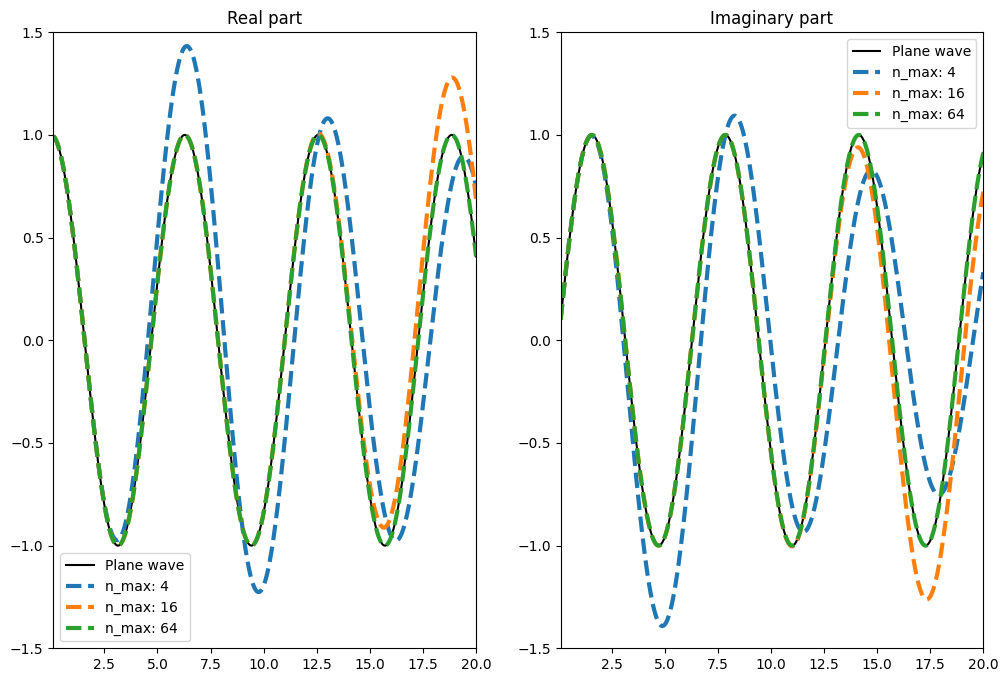

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 8))
ax1.plot(z_s, plane_wave.real, linestyle="solid", color="black", label="Plane wave")
for (n_max, jacobi_expansion) in zip(n_max_v, jacobi_expansion_v):
    ax1.plot(z_s, jacobi_expansion.real, linestyle="dashed", linewidth=3, label=f"n_max: {n_max}")
ax1.legend();
ax1.set_ylim(-1.5, 1.5);
ax1.set_xlim(z_s.min(), z_s.max());

ax2.plot(z_s, plane_wave.imag, linestyle="solid", color="black", label="Plane wave")
for (n_max, jacobi_expansion) in zip(n_max_v, jacobi_expansion_v):
    ax2.plot(z_s, jacobi_expansion.imag, linestyle="dashed", linewidth=3, label=f"n_max: {n_max}")
ax2.legend();
ax2.set_ylim(-1.5, 1.5);
ax2.set_xlim(z_s.min(), z_s.max());
ax1.set_title("Real part")
ax2.set_title("Imaginary part");

### Now we find the enhancement of the local field upon plane wave excitation. We write the magnetic field (polarized in the $e_z$ direction) outside of the scatterer as  as $2He^{ikr\cos(\theta)}=\sum_{m=-\infty}^{\infty} (i)^m \Bigg[H^{(1)}_m(kr)+H^{(2)}_m(kr)+(s_m-1)H^{(1)}_m(kr)\Bigg]e^{im\theta}$. In this expression, $s_m$ is the scattering coefficient we obtain through, for instance, *h_z_cpa* in *utils.py*. Therefore, we need to calculate all $s_m$ for $|m|<m_{max}$, where $m_{max}$ is some cutoff

In [5]:
lambda_air = 532 # wavelength in air of the incident light in nm
R = 5.1 # Radius of the cylindrical scatterer
x = (2*pi/lambda_air)*R # kR
m_max = 10

In [6]:
def E_scatterer_s(s, m, lambda_air, r):
    k = (2*pi/lambda_air)
    kr = k*r
    if s==1:
        return (1j*m/r)*(jv(m, kr)), -k*(jvp(m, kr)) # If s=1, to avoid numerical issues, we go directly to the Bessel functions of the first kind 
        #instead of representing them as sums of Hankel functions
    return (1j*m/r)*(hankel2(m, kr) + s*hankel1(m, kr))/2, -k*(hl2_prime(m, kr) + s*hl1_prime(m, kr))/2 

In [82]:
ms = [1, 2]
thetas = linspace(0, 11, 12)*2*pi/12
epsilon_m_1 = -1.0116 # approximate epsilon for s_1=-1 for
epsilon_m_2 = -1.0012159 # approximate epsilon for s_2=-1
normalized_scatterer_intensity_v_v = []
for (chosen_m, epsilon_m) in zip(ms, [epsilon_m_1, epsilon_m_2]):
    print(f"Chosen_m: {chosen_m}")
    normalized_scatterer_intensity_v = []
    for theta in thetas:
        s_m_v = []
        for m in range(-m_max, m_max):
            s_m = h_z_cpa(m, x, epsilon_m+0j)
            s_m_v.append(s_m)
            
        s_m_v_fixed = []
        for (m, s_m) in zip(range(-m_max, m_max), s_m_v):
            if m==-chosen_m or m==chosen_m: # We assume epsilon has been tuned perfectly
                s_m_v_fixed.append(-1+0j)
            else:
                s_m_v_fixed.append(s_m.round(5))
    
        E_scatterer_rho = 0 + 0j
        E_scatterer_theta = 0 + 0j
        E_vacuum_rho = 0 + 0j
        E_vacuum_theta = 0 + 0j
        N = 20
        rs = linspace(R, 10, N) # From just outside the cylinder to 150 nanometers
        
        s_m_v_vacuum = np.ones_like(s_m_v) # In vacuum, s=1 exactly
        for (m, s_m, s_m_vacuum) in zip(range(-m_max, m_max), s_m_v_fixed, s_m_v_vacuum):
            E_scatterer_rho_m, E_scatterer_theta_m = E_scatterer_s(s_m, m, lambda_air, rs)
            E_vacuum_rho_m, E_vacuum_theta_m = E_scatterer_s(s_m_vacuum, m, lambda_air, rs)
        
            E_scatterer_rho += (1j)**m*E_scatterer_rho_m*exp(1j*m*theta)
            E_scatterer_theta += (1j)**m*E_scatterer_theta_m*exp(1j*m*theta)
        
            E_vacuum_rho += (1j)**m*E_vacuum_rho_m
            E_vacuum_theta += (1j)**m*E_vacuum_theta_m
        scatterer_intensity = np.abs(E_scatterer_theta)**2+np.abs(E_scatterer_rho)**2
        vacuum_intensity = np.abs(E_vacuum_theta)**2+np.abs(E_vacuum_rho)**2
        normalized_scatterer_intensity = scatterer_intensity/(vacuum_intensity).max()
        normalized_scatterer_intensity_v.append(normalized_scatterer_intensity)
    normalized_scatterer_intensity_v_v.append(normalized_scatterer_intensity_v)
max_m_1 = max([max(normalized_scatterer_intensity) for normalized_scatterer_intensity in normalized_scatterer_intensity_v_v[0]])
max_m_2 = max([max(normalized_scatterer_intensity) for normalized_scatterer_intensity in normalized_scatterer_intensity_v_v[1]])
print("Maximum enhancement for m=1 (divided by 1e5): ", max_m_1/1e5);
print("Maximum enhancement for m=1 (divided by 1e8): ", max_m_2/1e8);

Chosen_m: 1
Chosen_m: 2
Maximum enhancement for m=1 (divided by 1e5):  1.2629571355638138
Maximum enhancement for m=1 (divided by 1e8):  5.500970924836189


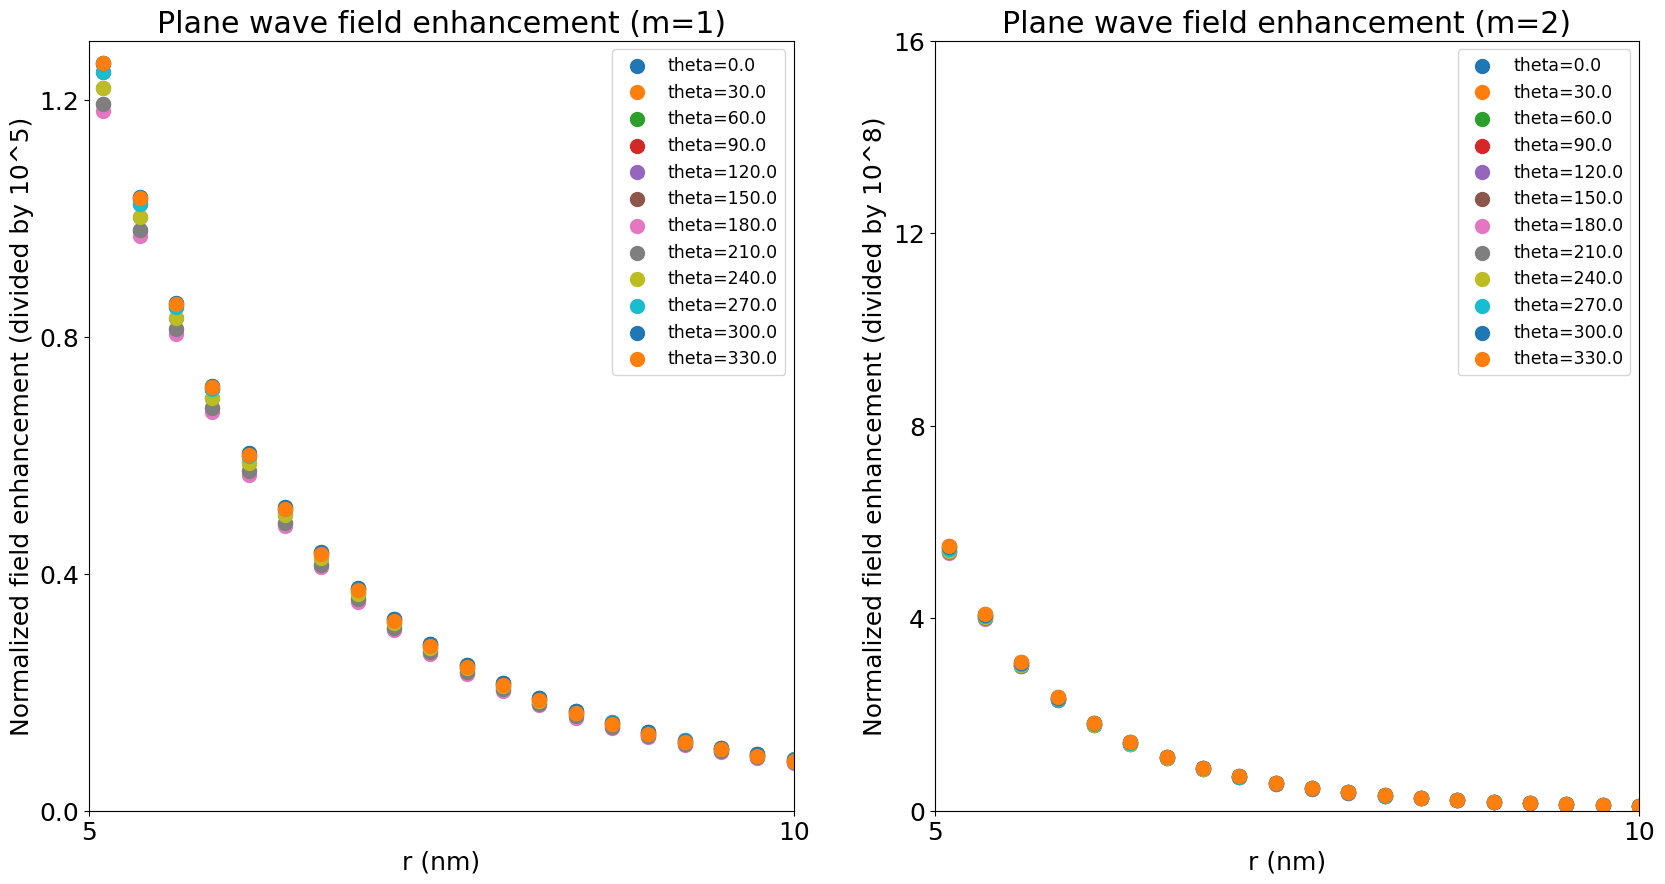

In [87]:
plt.rcParams.update({'font.size': 18})
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
for (theta_idx, theta) in enumerate(thetas):
    ax1.scatter(rs, normalized_scatterer_intensity_v_v[0][theta_idx]/1e5, linewidth=1, label=f"theta={(theta/(2*pi)*360).round(3)}", s=100)
    ax1.set_ylim(0, 1.3)
    ax2.scatter(rs, normalized_scatterer_intensity_v_v[1][theta_idx]/1e8, linewidth=1, label=f"theta={(theta/(2*pi)*360).round(3)}", s=100)
ax2.set_ylim(0, 16);
ax1.set_xlim(5, 10)
ax2.set_xlim(5, 10);
ax1.set_title("Plane wave field enhancement (m=1)")
ax2.set_title("Plane wave field enhancement (m=2)")
ax1.set_xlabel("r (nm)")
ax2.set_xlabel("r (nm)")
ax1.set_ylabel("Normalized field enhancement (divided by 10^5)")
ax2.set_ylabel("Normalized field enhancement (divided by 10^8)");
ax1.set_xticks([5, 10])
ax1.set_yticks([0, 0.4, 0.8, 1.2])
ax2.set_xticks([5, 10])
ax2.set_yticks([0, 4, 8, 12, 16]);
ax1.legend(fontsize="x-small");
ax2.legend(fontsize="x-small");

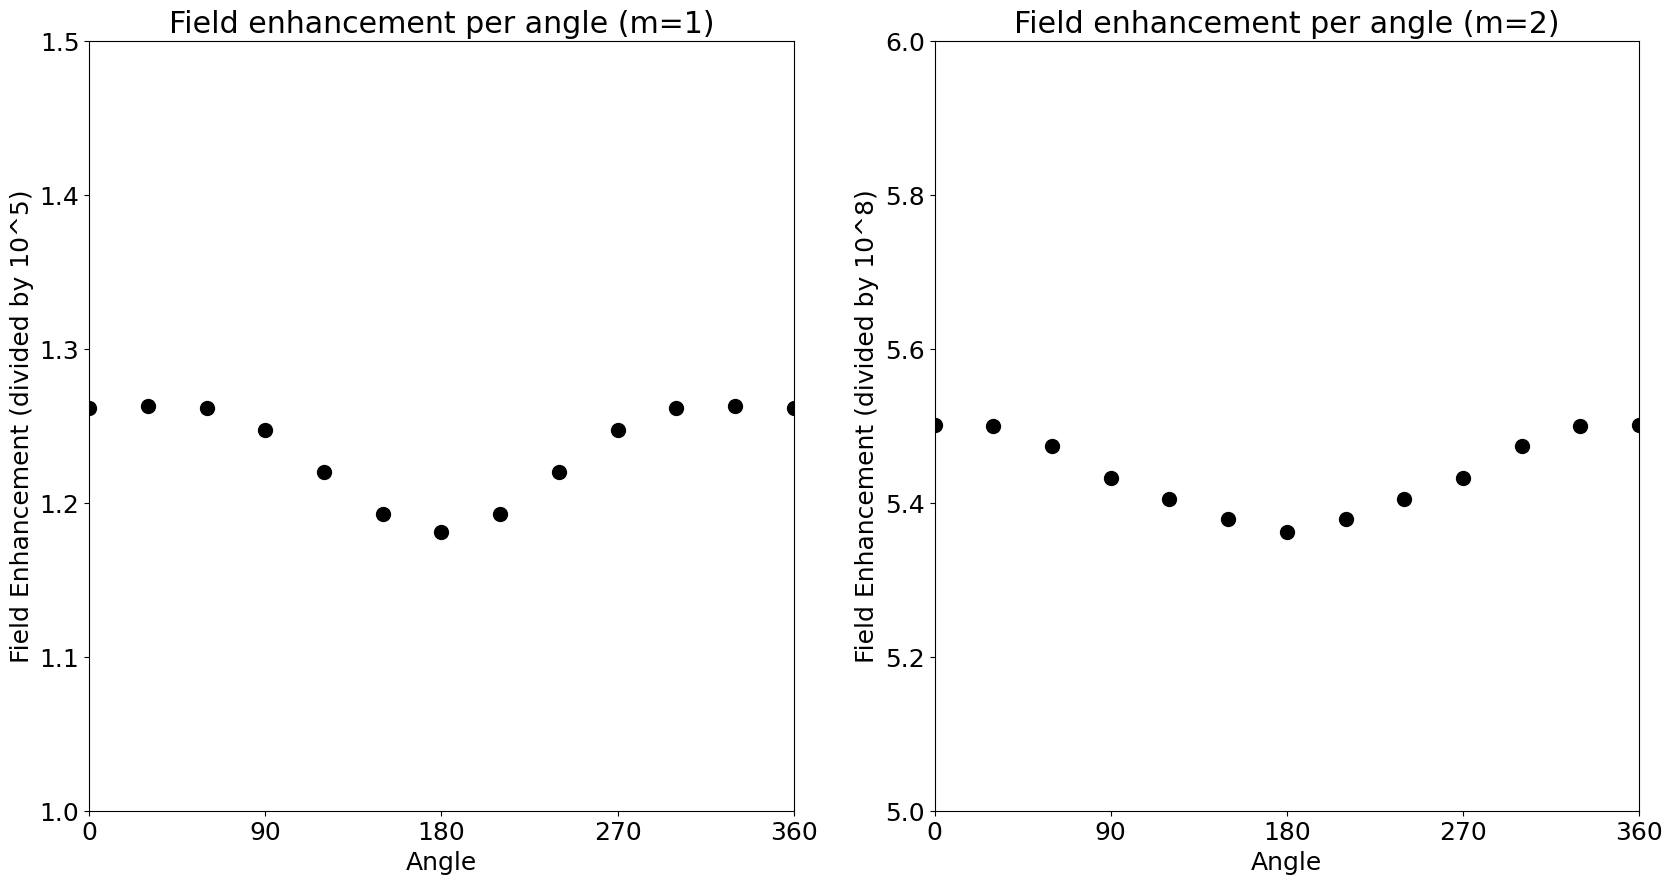

In [101]:
enhancement_per_angle_m_1 = np.array([x[0] for x in normalized_scatterer_intensity_v_v[0]])
enhancement_per_angle_m_2 = np.array([x[0] for x in normalized_scatterer_intensity_v_v[1]])
enhancement_per_angle_m_1 = np.array([*enhancement_per_angle_m_1, enhancement_per_angle_m_1[0]])
enhancement_per_angle_m_2 = np.array([*enhancement_per_angle_m_2, enhancement_per_angle_m_2[0]])

thetas_prime = np.linspace(0, 360, len(enhancement_per_angle_m_1))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
ax1.scatter(thetas_prime, enhancement_per_angle_m_1/1e5, s=100, color="black")
ax1.set_xlim(0, 360)
ax1.set_xlabel("Angle")
ax1.set_ylabel("Field Enhancement (divided by 10^5)")
ax1.set_ylim(1, 1.5);
ax2.scatter(thetas_prime, enhancement_per_angle_m_2/1e8, s=100, color="black")
ax2.set_xlim(0, 360)
ax2.set_xlabel("Angle")
ax2.set_ylabel("Field Enhancement (divided by 10^8)");
ax2.set_ylim(5, 6);
ax1.set_xticks([0, 90, 180, 270, 360])
ax2.set_xticks([0, 90, 180, 270, 360])
ax1.set_title("Field enhancement per angle (m=1)")
ax2.set_title("Field enhancement per angle (m=2)");

## Time domain calculations

In [3]:
sigma_t = 3.3/sqrt(2) # Width of the Gaussian in the time domain (in femtoseconds)
sigma_omega = 1/sigma_t
def gaussian_pulse(t):
    return exp(-t**2/(2*sigma_t**2))

In [4]:
N = 1000
omegas = linspace(-10, 10, N)
c = 300 # speed of light in nm/fs 
lambda_air = 532
omega_c = 2*pi*c/532
fourier_transform_quad = [quad(lambda t: cos((omega-omega_c)*t)*gaussian_pulse(t), -10, 10)[0] for omega in omegas]
fourier_transform_analytic = (sqrt(2*pi)/sigma_omega)*exp(-(omegas-omega_c)**2/(2*sigma_omega**2))

### We compare the Fourier transform of the pulse as obtained by scipy.quad with the analytically known Fourier transform of a shifted Gaussian

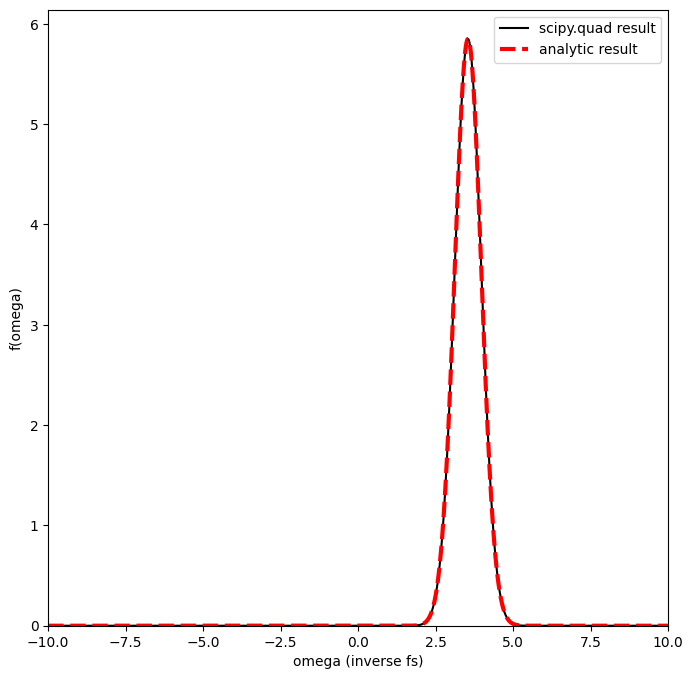

In [5]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(omegas, fourier_transform_quad, color="black", label="scipy.quad result")
ax.plot(omegas, fourier_transform_analytic, linestyle="dashed", linewidth=3, color="red", label="analytic result");
ax.legend();
ax.set_xlim(omegas.min(), omegas.max());
ax.set_ylim(0, None);
ax.set_xlabel("omega (inverse fs)");
ax.set_ylabel("f(omega)");

### Now we calculate the FWHM in the wavelength domain

In [6]:
max_signal = np.max(fourier_transform_quad) # Maximum of f(omega)
omega_hwhm = omegas[np.argmin(np.abs(fourier_transform_quad-max_signal/2))] # omega corresponding to f(omega) = max(f(omega))/2
print("FWHM in wavelength domain: ", 2*(2*pi*c/omega_hwhm-lambda_air).round(3), " nm") 

FWHM in wavelength domain:  178.95  nm


Now we calculate the Fourier transform directly with scipy.ifft. Note that this calculates, explicitly, $\tilde{y}[n]=\frac{1}{N}\sum_k e^{2\pi i nk/N} y[k]$, whereas we would like to calculate the quantity $\int_{-T}^{T} e^{i\omega t} y(t)\text{d}t=2T\int_{0}^{1}e^{i\omega T u} y(Tu)\text{d}u=2\frac{T}{N}\sum_{k=0}^{N} e^{i(k/N)(\omega T)} y(T(k/N))$, with $\omega=2\pi n/T$

In [7]:
N = 100000
T = 1000
t_s = linspace(0, T, N)
omega_grid = linspace(0, N-1, N)
fft_direct = 2*T*ifft(gaussian_pulse(t_s)*exp(-1j*t_s*omega_c))
omega_fft = np.where(omega_grid>N/2, omega_grid-N, omega_grid)*2*pi/T

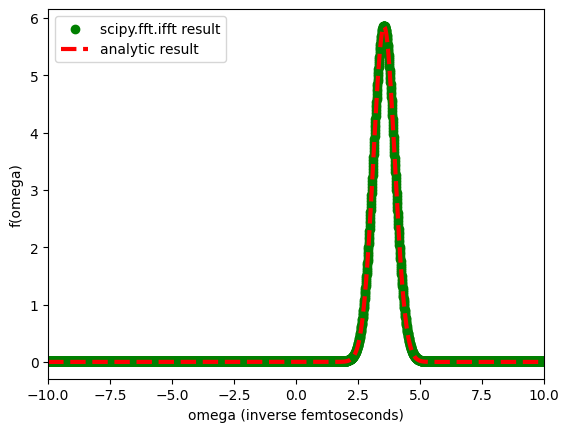

In [8]:
plt.scatter(omega_fft, fft_direct.real, color="green", label="scipy.fft.ifft result")
plt.plot(omegas, fourier_transform_analytic, linestyle="dashed", linewidth=3, color="red", label="analytic result");
plt.xlim(-10, 10);
#plt.ylim(0, None);
plt.xlabel("omega (inverse femtoseconds)");
plt.ylabel("")
plt.legend();
plt.ylabel("f(omega)");

### We now re-produce the time domain curve shown in Figure 6c of the paper. In this figure, a perfectly absorbing cylinder (over a range of $\approx 200$ nanometers in wavelength is excited with a Gaussian pulse (with all frequency components within the perfectly absorbing wavelength range). We are only concerned with the field intensities just outside the cylinder, so we need not calculate $E_r$ or $E_\theta$ for $r<5.1$

### Explicitly, we calculate for $s=1$ (vacuum) and $s=0$ (coherent perfect absorber), the quantity:

$\mathbf{E}(t)=\int_{-\infty}^{\infty}e^{-i\omega t}\Bigg[\frac{im}{r}\Big[H_m^{(2)}(r\omega/c)+s H_m^{(1)}(r\omega/c) \Big] e_r -\frac{\omega}{c}\Big[H_m^{(2)}(r\omega/c)'+s H_m^{(1)}(r\omega/c)' \Big]e_\theta \Bigg]f(\omega)\text{d}\omega + c.c$, 

where $f(\omega)$ is the Fourier transform of the pulse (which we already calculated above)

In [9]:
# Electric field in vacuum (s=1, which means we only have a Bessel function of the first kind)
c = 300 # speed of light in nm/fs
r = 5.1
m = 1
def E_vacuum_rho(omega):
    k = omega/c
    kr = k*r
    return (m/r)*jv(m, kr) # We put the factor of i in the integral below
def E_vacuum_theta(omega):
    k = omega/c
    kr = k*r
    return -k*jvp(m, kr) # E_rho, E_theta
# Electric field for a perfectly absorbing scatterer (for r>R) (s=-1 so we only have a Bessel function of the second kind outside the scatterer
# Note that we have a factor of 1/2 as compared to the passive sink since some of the Hankel function is absorbed. 
def E_scatterer_rho(omega):
    k = omega/c
    kr = k*r
    return (m/r)*yv(m, kr)/2 # We put the factor of i in the integral below
def E_scatterer_theta(omega):
    k = omega/c
    kr = k*r
    return -k*yvp(m, kr)/2

In [10]:
# f(omega) 
def fourier_gaussian(omega):
    return (sqrt(2*pi)/sigma_omega)*exp(-(omega-omega_c)**2/(2*sigma_omega**2))

In [11]:
M = 50
Ts_6c = linspace(-10, 10, M)
E_vacuum_rho_t = [quad(lambda omega: sin(omega*t)*fourier_gaussian(omega)*E_vacuum_rho(omega), 1, 5)[0] for t in Ts_6c]
E_vacuum_theta_t = [quad(lambda omega: cos(omega*t)*fourier_gaussian(omega)*E_vacuum_theta(omega), 1, 5)[0] for t in Ts_6c]

E_scatterer_rho_t = [quad(lambda omega: sin(omega*t)*fourier_gaussian(omega)*E_scatterer_rho(omega), 1, 5)[0] for t in Ts_6c]
E_scatterer_theta_t = [quad(lambda omega: cos(omega*t)*fourier_gaussian(omega)*E_scatterer_theta(omega), 1, 5)[0] for t in Ts_6c]

vacuum_intensity = np.abs(E_vacuum_rho_t)**2+np.abs(E_vacuum_theta_t)**2
scatterer_intensity = np.abs(E_scatterer_rho_t)**2+np.abs(E_scatterer_theta_t)**2

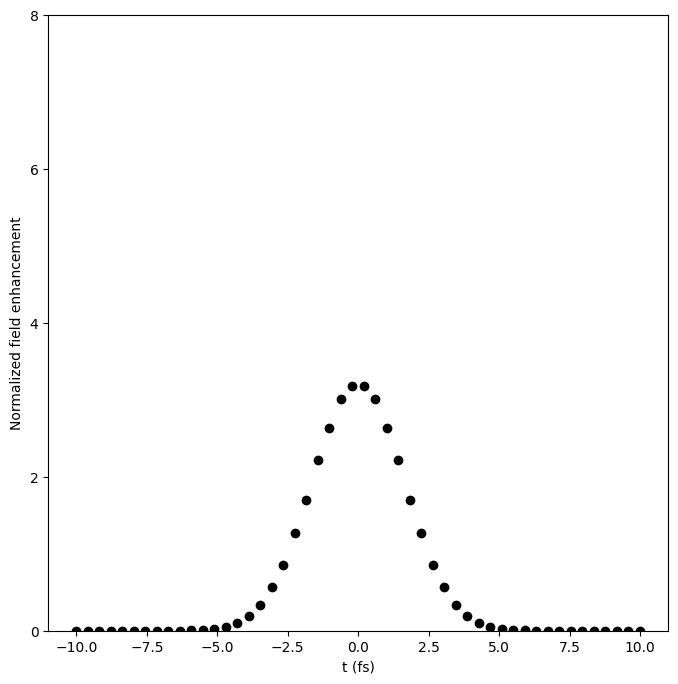

In [12]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(Ts_6c, scatterer_intensity/vacuum_intensity.max()/1e4, color="black")
ax.set_ylim(0, 8)
ax.set_xlabel("t (fs)");
ax.set_ylabel("Normalized field enhancement");
ax.set_yticks(linspace(0, 8, 5));

### We do the same as the above, this time with scipy.fft 
scipy.fft computes the quantity $\tilde{f}(k)=\sum_{n}e^{2\pi i nk/N} f(n)$. We identify $\omega=2\pi n/T$ and $t=(k/N)T$

In [87]:
N = 100000
T = 10000
omegas = linspace(0, N, N)*2*pi/T

scatter_rho_array = fourier_gaussian(omegas)*E_scatterer_rho(omegas)
scatter_rho_array = np.where(np.abs(scatter_rho_array) == np.inf, 0, scatter_rho_array)

scatter_theta_array = fourier_gaussian(omegas)*E_scatterer_theta(omegas)
scatter_theta_array = np.where(np.isnan(scatter_theta_array), 0, scatter_theta_array)

fft_scatterer_rho = fft(1j*scatter_rho_array).real**2
fft_scatterer_theta = fft(scatter_theta_array).real**2

vacuum_rho_array = fourier_gaussian(omegas)*E_vacuum_rho(omegas)
vacuum_theta_array = fourier_gaussian(omegas)*E_vacuum_theta(omegas)

fft_vacuum_rho = fft(1j*vacuum_rho_array).real**2
fft_vacuum_theta = fft(vacuum_theta_array).real**2
max_vacuum = (fft_vacuum_rho + fft_vacuum_theta).max()

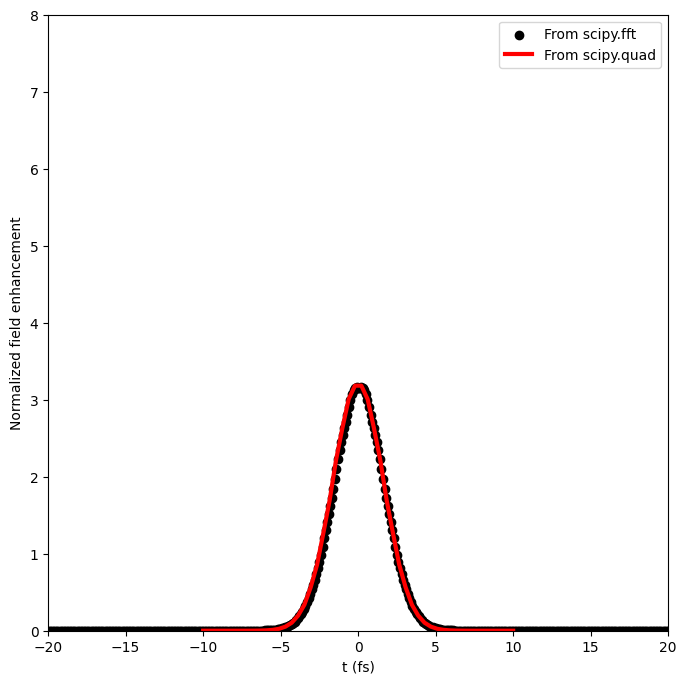

In [98]:
t_array = linspace(0, T, N)
t_array = np.where(t_array > T/2, t_array - T, t_array)
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(t_array, (fft_scatterer_rho + fft_scatterer_theta)/max_vacuum/1e4, color="black", label="From scipy.fft")
ax.plot(Ts_6c, scatterer_intensity/vacuum_intensity.max()/1e4, color="red", linewidth=3, label="From scipy.quad")
ax.set_ylim(0, 8);
ax.set_xlabel("t (fs)");
ax.set_ylabel("Normalized field enhancement");
ax.legend()
ax.set_xlim(-20, 20);